# Hierarchical Agent란?

**Hierarchical Agent**는 계층적 구조로 작업을 **분류하고 위임**하는 Multi-Agent 패턴입니다.



### 핵심 특징

1. **단순 분류와 실행** (Classify & Execute)
   - 상위 에이전트가 입력을 분석하여 적절한 하위 에이전트로 라우팅
   - 한 번의 분류로 작업 완료 (1회성 실행)
   
2. **명확한 역할 분담** (Clear Role Division)
   - 각 하위 에이전트는 특정 도메인에 특화
   - 서로 독립적으로 작동
   
3. **조건부 라우팅** (Conditional Routing)
   - 입력 내용에 따라 다른 경로로 분기
   - if-else 로직과 유사한 흐름

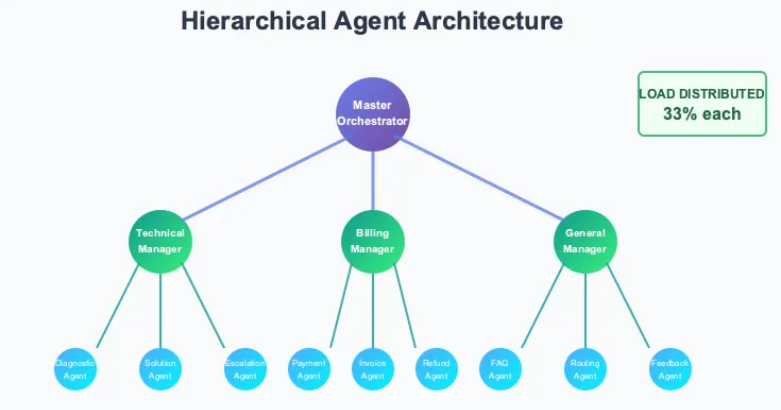

# Multi Agents - 고객 지원 챗봇
LangGraph를 활용하여 여러 에이전트가 협력하는 고객 지원 챗봇을 구현합니다.


### 작동 방식

```
사용자 입력
    ↓
분류 에이전트 (Classifier)
    ↓
조건부 라우팅
    ├─→ 에이전트 A (특정 업무)
    ├─→ 에이전트 B (특정 업무)
    └─→ 에이전트 C (특정 업무)
    ↓
최종 응답
```


### 적합한 사용 사례

- 고객 지원 시스템 (기술/결제/일반 상담)
- 문서 분류 및 처리
- 이메일 자동 라우팅
- 간단한 의사결정 트리


## 구성
1. **분류 에이전트**: 고객 문의 유형을 판단 (기술/결제/일반)
2. **기술 지원 에이전트**: 기술 문제 해결
3. **결제 지원 에이전트**: 결제 관련 처리
4. **일반 상담 에이전트**: 일반 문의 응답


### 이 예제가 Hierarchical Agent인 이유

**고객 지원 챗봇**은 Hierarchical Agent의 전형적인 사례입니다:

1. **분류 단계**: 고객 문의를 분석하여 유형 판단 (기술/결제/일반)
2. **라우팅**: 문의 유형에 따라 전문 에이전트로 분기
3. **독립 실행**: 각 지원 에이전트가 자신의 영역만 처리
4. **1회성 완료**: 한 번의 라우팅으로 작업 종료

**vs. Supervisor Agent**: Supervisor는 여러 에이전트를 순차적으로 조율하지만, Hierarchical은 단순히 하나의 에이전트를 선택하여 실행합니다.

## LangSmith - 로그 추적

langsmith는 langchain에서 만든 온라인 기반의 LLM 애플리케이션 모니터링, 테스트 지원, 배포 지원 도구이다.

### [Concepts](https://docs.smith.langchain.com/observability/concepts)
- `Trace`는 애플리케이션이 입력에서 출력으로 가는 일련의 단계를 의미합니다. 
    - 이 각각의 개별 단계는 `Run`으로 표현됩니다.
- `Project`는 단순히 여러 개의 `Trace` 모음입니다.

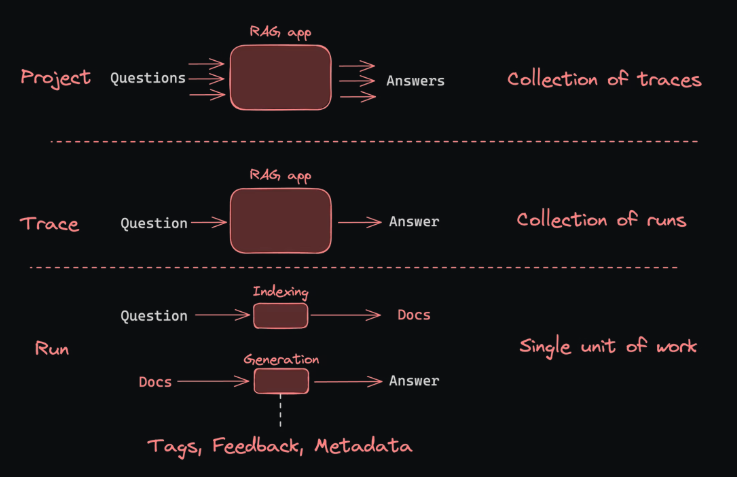

### [LangSmith 사이트](https://smith.langchain.com/)에 접속하여 회원가입

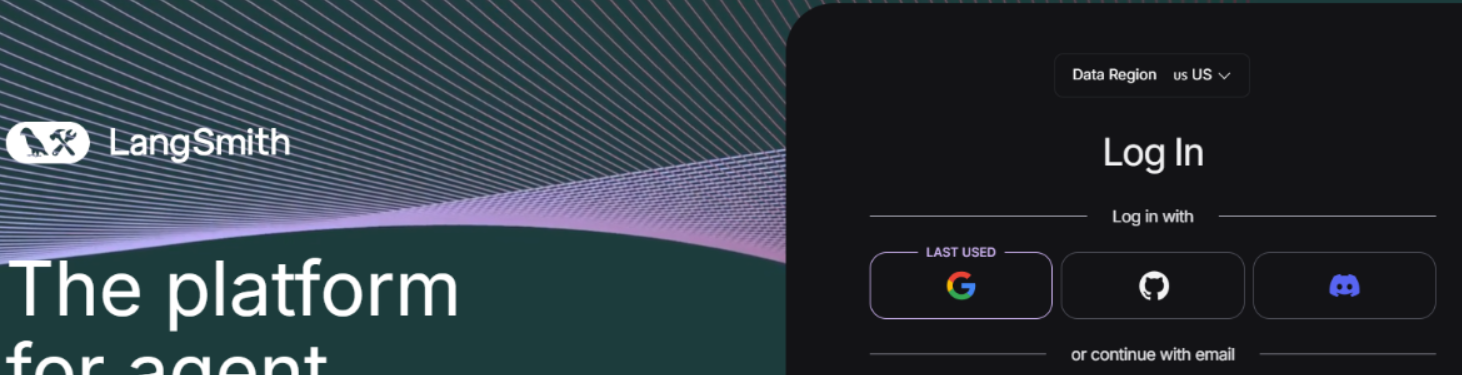

### [API Key 생성하기](https://smith.langchain.com/)

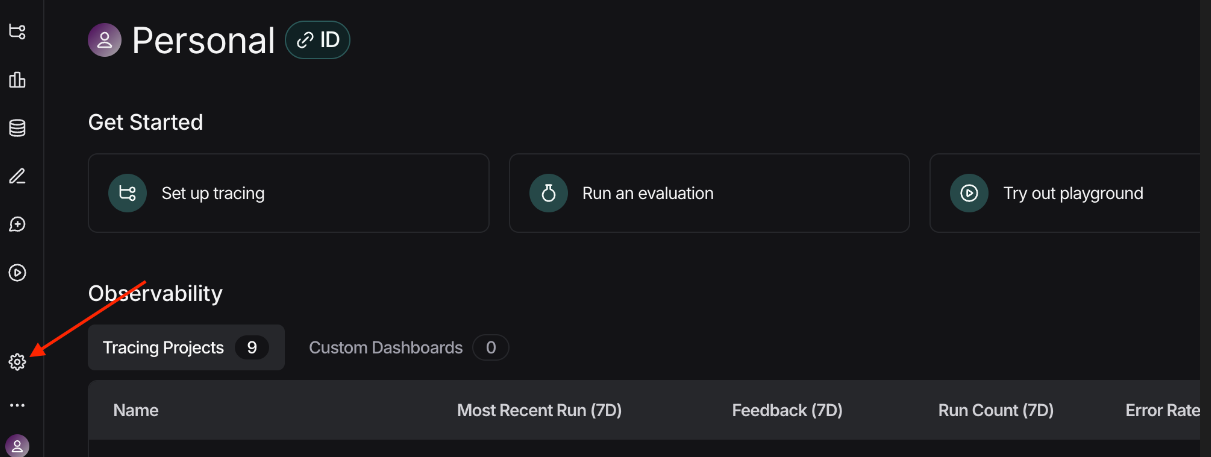

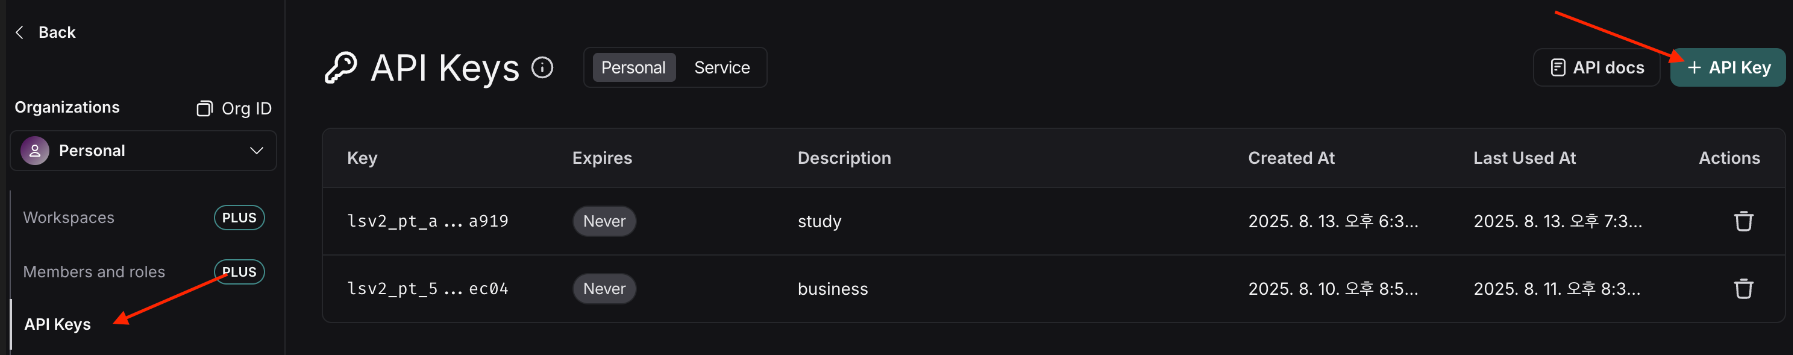

### API Key 환경변수(.env)에 등록
- `LANGCHAIN_TRACING_V2`: "true" 로 설정하면 추적을 시작합니다.
- `LANGCHAIN_ENDPOINT`: https://api.smith.langchain.com 변경하지 않습니다.
- `LANGCHAIN_API_KEY`: 이전 단계에서 발급받은 키 를 입력합니다.
- `LANGCHAIN_PROJECT`: 프로젝트 명 을 기입하면 해당 프로젝트 그룹으로 모든 실행(Run) 이 추적됩니다.

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## 학습 목표
- 조건부 라우팅 (conditional routing)
- 상태 관리 (state management)
- 여러 에이전트 중 선택적 실행

## 1단계: LLM 모델 초기화 


### [Ollama](https://ollama.com/)
- 오픈소스 대형 언어 모델(LLM)을 내 컴퓨터에서 직접 실행할 수 있게 해주는 도구입니다.
- 간단히 말하면: ChatGPT 같은 AI를 인터넷 없이 내 PC에서 무료로 사용할 수 있습니다.

- [Install Ollama](https://ollama.com/download/windows)

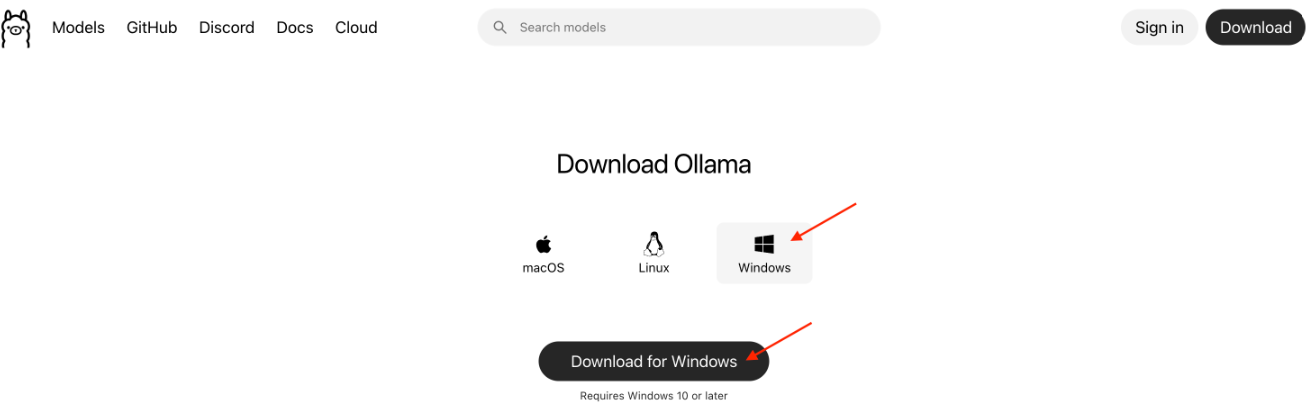

- 설치 결과 확인 
    ```shell
    ollama --version
    ```

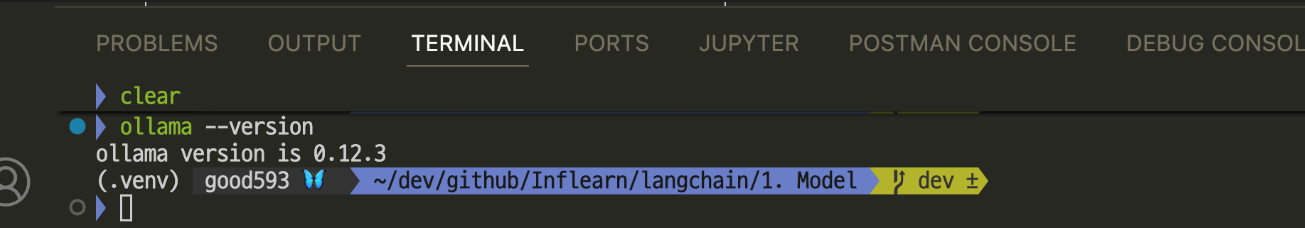

- [Ollama Models](https://ollama.com/search)

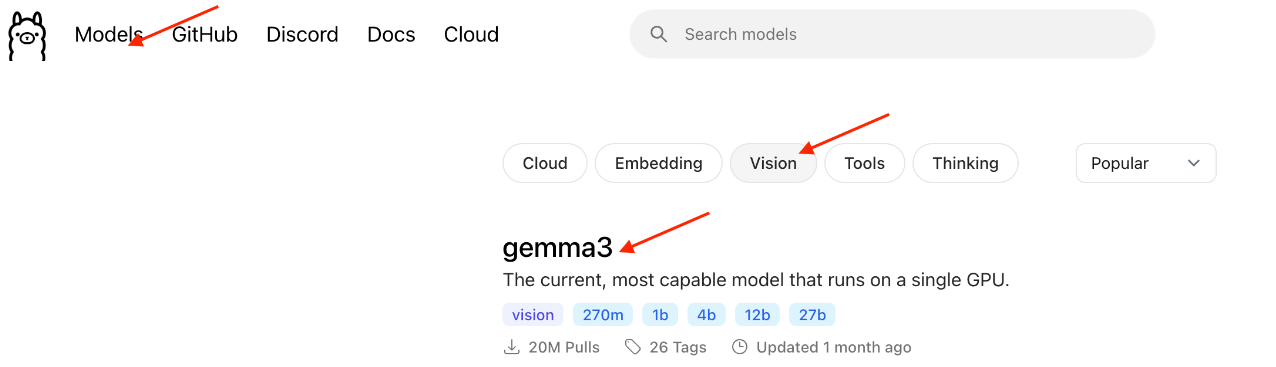

- 모델 다운로드 하기 
    ```shell
    ollama pull gemma3:4b
    ```
- 모델 다운로드 확인 
    ```shell
    ollama list
    ```

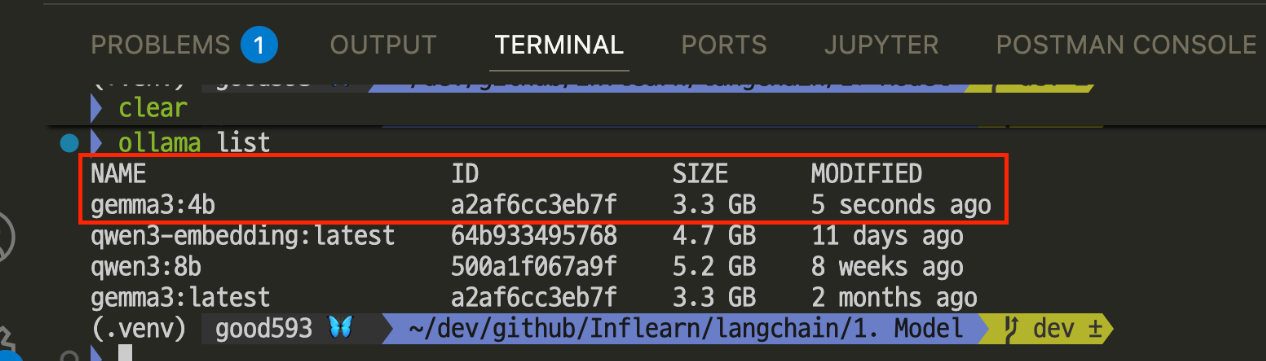

In [2]:
from langchain_ollama.chat_models import ChatOllama 

llm = ChatOllama(
    model="gemma3:4b",
    temperature=0.1,
    top_p=1.0,
    keep_alive="5m"
)

## 2단계: 상태 정의 (State Management)

그래프에서 사용할 상태 구조를 정의합니다. 상태는 모든 노드 간에 공유되며, 각 에이전트가 정보를 추가하거나 수정할 수 있습니다.


In [3]:
from typing import TypedDict, NotRequired, Literal

class SupportState(TypedDict):
    """
    고객 지원 챗봇의 상태를 표현하는 타입.

    Attributes:
        question (str): 고객이 입력한 원본 문의 내용.
        category (Literal["technical", "billing", "general"] | None):
            분류 에이전트가 판별한 문의 유형.
            초기 상태에서는 None일 수 있음.
        response (NotRequired[str]):
            최종 지원 에이전트가 생성한 응답 메시지.
            아직 생성되지 않은 경우 omitted(없음)이 될 수 있음.
    """

    question: str
    category: Literal["technical", "billing", "general"] | None
    response: NotRequired[str]
    


## 3단계: 에이전트 노드 정의

각 에이전트의 역할과 기능을 정의합니다.


### 분류 에이전트 (Classifier Agent)

고객의 문의 내용을 분석하여 적절한 지원 유형으로 분류합니다.


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def classifier_agent(state: SupportState) -> SupportState:
    """
    고객 문의를 분석하여 적절한 카테고리로 분류하는 에이전트
    """
    question = state["question"]
    
    # LLM을 사용하여 문의 유형 분류
    messages = [
        SystemMessage(content="""
            당신은 고객 문의를 분류하는 전문가입니다.
            고객의 문의를 다음 세 가지 카테고리 중 하나로 분류하세요:

            1. technical - 기술적 문제, 오류, 버그, 기능 작동 문제 등
            2. billing - 결제, 환불, 요금제, 구독 관련 문제
            3. general - 일반 문의, 제품 정보, 사용 방법 등

            반드시 'technical', 'billing', 'general' 중 하나의 단어만 응답하세요."""),
        HumanMessage(content=f"다음 문의를 분류하세요: {question}")
    ]
    
    response = llm.invoke(messages)
    category = response.content.strip().lower()
    
    print(f"[분류 에이전트] 문의 유형: {category}")
    
    return {
        "question": question,
        "category": category
    }


In [5]:
# 테스트
test_state = {"question": "로그인이 안됩니다"}
result = classifier_agent(test_state)
print(f"분류 결과: {result['category']}")

[분류 에이전트] 문의 유형: technical
분류 결과: technical


### 기술 지원 에이전트

기술적인 문제를 해결하는 전문 에이전트입니다.


In [9]:
def technical_support_agent(state: SupportState) -> SupportState:
    """
    기술적 문제를 해결하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 기술 지원 전문가입니다.
            고객의 기술적 문제를 친절하고 명확하게 해결해주세요.
            단계별 해결 방법을 제시하고, 가능한 원인을 설명하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[기술 지원 에이전트] 응답 생성 완료")
    
    return {
        **state,
        "response": answer
    }


In [10]:
test_state = {"question": "앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?"}
result = technical_support_agent(test_state)
print(f"기술적 문제 답변: {result['response']}")

[기술 지원 에이전트] 응답 생성 완료
기술적 문제 답변: 안녕하세요! 앱이 계속해서 강제 종료되는 문제로 불편을 겪고 계시다니 정말 안타깝습니다. 하지만 걱정 마세요. 제가 단계별로 해결 방법을 안내해 드리겠습니다. 문제 해결을 위해 몇 가지 단계를 밟아보겠습니다.

**1단계: 문제 재현 확인 및 기록**

*   **어떤 앱에서 발생하나요?** 특정 앱에서만 발생하는 문제인지, 아니면 여러 앱에서 모두 발생하는 문제인지 확인합니다.
*   **언제 강제 종료되나요?** 앱을 실행할 때, 특정 기능을 사용할 때, 또는 아무 때나 갑자기 강제 종료되는지 확인합니다.
*   **강제 종료되기 전에 어떤 화면이 표시되나요?** 오류 메시지나 경고 메시지가 있는지 확인하고, 가능하다면 메시지 내용을 기록해 두세요.
*   **강제 종료 후에는 어떻게 되나요?** 앱이 자동으로 재시작되는지, 아니면 다시 강제 종료되는지 확인합니다.

이러한 정보를 기록해 두면 문제 해결에 도움이 됩니다.

**2단계: 기본적인 해결 방법**

*   **휴대폰 재부팅:** 가장 간단하지만 효과적인 해결 방법 중 하나입니다. 일시적인 오류를 해결할 수 있습니다.
*   **앱 데이터 삭제:** 앱의 캐시 및 데이터가 손상되어 문제가 발생할 수 있습니다.
    *   **Android:** 설정 > 앱 > 문제 앱 선택 > 저장 공간 관리 > 데이터 삭제
    *   **iOS:** 설정 > 앱 > 문제 앱 선택 > 저장 공간 관리 > 삭제
    *   **주의:** 데이터 삭제 시 앱 설정, 로그인 정보 등 모든 데이터가 삭제될 수 있습니다.
*   **앱 캐시 삭제:** 앱 캐시만 삭제하여 앱의 성능을 개선할 수 있습니다.
    *   **Android:** 설정 > 앱 > 문제 앱 선택 > 캐시 삭제
    *   **iOS:** 설정 > 앱 > 문제 앱 선택 > 캐시 삭제
*   **앱 업데이트 확인:** 앱의 버그 수정 및 성능 개선을 위한 업데이트가 있을 수 있습니다

### 결제 지원 에이전트

결제 및 청구 관련 문제를 처리하는 에이전트입니다.


In [11]:
def billing_support_agent(state: SupportState) -> SupportState:
    """
    결제 및 청구 관련 문제를 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 결제 및 청구 관련 전문 상담원입니다.
            고객의 결제, 환불, 요금제 관련 문의에 정확하고 친절하게 답변하세요.
            필요한 경우 정책과 절차를 안내하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[결제 지원 에이전트] 응답 생성 완료")
    
    return {
        **state,
        "response": answer
    }


In [12]:
test_state = {"question": "구독을 취소하고 환불받고 싶습니다."}
result = billing_support_agent(test_state)
print(f"결제 및 청구 관련 문제 답변: {result['response']}")

[결제 지원 에이전트] 응답 생성 완료
결제 및 청구 관련 문제 답변: 안녕하세요. 고객님, 구독 취소 및 환불 문의 주셔서 감사합니다. 불편을 드려 죄송합니다. 

고객님의 상황을 정확하게 파악하고 도움을 드리기 위해 몇 가지 질문을 드려도 될까요?

1.  **어떤 서비스에 대한 구독을 취소하고 싶으신가요?** (예: 월간 멤버십, 연간 구독 등)
2.  **구독 계정 정보 (이메일 주소 또는 사용자 이름)를 알려주실 수 있나요?** 계정 정보를 확인하여 정확한 정보를 확인하고 처리할 수 있습니다.
3.  **구독 취소 이유를 말씀해주실 수 있나요?** (예: 서비스 이용 불량, 개인적인 사유 등)
4.  **환불을 받으려는 기간을 알려주세요.** (예: 현재 사용 중인 기간, 특정 월의 요금 등)

**일반적인 구독 취소 및 환불 정책은 다음과 같습니다.**

*   **취소 절차:** 구독 서비스의 종류에 따라 취소 절차가 다를 수 있습니다. 대부분의 경우, 계정 설정 페이지나 고객센터를 통해 구독을 취소할 수 있습니다.
*   **환불 정책:**
    *   **취소 시점:** 구독 취소 요청이 접수된 시점부터 환불이 적용됩니다.
    *   **환불 가능 기간:** 서비스 제공업체에 따라 환불 가능 기간이 다릅니다. 일반적으로 취소 시점으로부터 7일 ~ 30일 이내에 환불이 가능합니다.
    *   **환불 금액:** 환불 가능한 금액은 잔여 사용 기간에 따라 달라집니다.
    *   **환불 방식:** 환불은 고객님께서 결제한 방식 (예: 신용카드, 계좌이체)으로 동일하게 처리됩니다.

**환불 절차는 다음과 같습니다.**

1.  고객센터에 문의하여 구독 취소 및 환불 신청
2.  환불 신청 시 필요한 정보 제공 (계정 정보, 환불 금액 등)
3.  환불 신청 승인 후 환불 진행 (환불 소요 기간은 결제 방식 및 서비스 제공업체에 따라 다를 수 있습니다.)

**주의사항:**

*   일부 서비스는 구독 기간이 지난 후에는 환불이 불가능할

### 일반 상담 에이전트

일반적인 문의사항을 처리하는 에이전트입니다.


In [13]:
def general_support_agent(state: SupportState) -> SupportState:
    """
    일반적인 문의사항을 처리하는 에이전트
    """
    question = state["question"]
    
    messages = [
        SystemMessage(content="""
            당신은 친절한 고객 상담원입니다.
            고객의 일반적인 문의에 친절하고 유용한 정보를 제공하세요.
            제품이나 서비스에 대한 설명을 명확하게 전달하세요."""),
        HumanMessage(content=question)
    ]
    
    response = llm.invoke(messages)
    answer = response.content
    
    print(f"[일반 상담 에이전트] 응답 생성 완료")
    
    return {
        **state,
        "response": answer
    }


In [14]:
test_state = {"question": "프리미엄 플랜에는 어떤 기능들이 포함되나요?"}
result = general_support_agent(test_state)
print(f"일반적인 문의사항 답변: {result['response']}")

[일반 상담 에이전트] 응답 생성 완료
일반적인 문의사항 답변: 안녕하세요! 프리미엄 플랜에 대해 문의주셔서 감사합니다. 프리미엄 플랜은 저희 서비스를 최대한 활용하실 수 있도록 설계된 가장 강력한 플랜입니다. 주요 기능들을 자세히 안내해 드릴게요.

**1. 무제한 사용:**

*   저장 공간: 프리미엄 플랜에서는 파일, 이미지, 비디오 등 모든 콘텐츠에 대해 무제한 저장 공간을 제공합니다. 더 이상 저장 공간에 대한 걱정 없이 자유롭게 콘텐츠를 저장하고 관리할 수 있습니다.
*   API 호출 횟수: API를 활용하는 개발자님들을 위해 API 호출 횟수 제한이 없습니다.

**2. 고급 기능:**

*   **실시간 협업:** 여러 사용자가 동시에 동일한 콘텐츠를 편집하고 공동 작업할 수 있습니다. 실시간 채팅 기능도 제공되어 원활한 소통이 가능합니다.
*   **고급 분석:** 사용자의 행동 패턴, 콘텐츠 성과 등을 심층적으로 분석할 수 있는 고급 분석 기능을 제공합니다. 이를 통해 콘텐츠 전략을 최적화하고 사용자 경험을 개선할 수 있습니다.
*   **맞춤형 워크플로우:** 사용자의 요구사항에 맞춰 워크플로우를 커스터마이징할 수 있습니다.
*   **우선 지원:** 기술적인 문제 발생 시, 저희 전문 지원팀으로부터 우선적인 지원을 받으실 수 있습니다. 평균 응답 시간은 1분 이내로, 빠른 문제 해결을 도와드립니다.

**3. 추가 혜택:**

*   **월별 워크숍:** 저희 서비스의 최신 기능 및 활용 팁을 배울 수 있는 월별 온라인 워크숍에 참여하실 수 있습니다.
*   **전문 컨설팅:** 서비스 활용에 대한 전문적인 컨설팅을 무료로 제공합니다.

**가격:**

*   월간: 99,000원
*   연간: 990,000원 (월 할인 혜택 제공)

**더 자세한 정보:**

*   **가격 페이지:** [https://www.example.com/premium-pricing](https://www.example.com/premium-pricing)

## 4단계: 조건부 라우팅 (Conditional Routing)

분류 결과에 따라 적절한 에이전트로 라우팅하는 함수를 정의합니다.


In [15]:
from typing import Literal

def route_question(state: SupportState) -> Literal["technical", "billing", "general"]:
    """
    분류된 카테고리에 따라 적절한 에이전트로 라우팅하는 함수
    """
    category = state["category"]
    
    print(f"[라우터] '{category}' 카테고리로 라우팅")
    
    # 카테고리에 따라 다음 노드 결정
    if category == "technical":
        return "technical"
    elif category == "billing":
        return "billing"
    else:
        return "general"


## 5단계: 그래프 구성

LangGraph를 사용하여 전체 워크플로우를 구성합니다.

In [16]:
from langgraph.graph import StateGraph, END, START

# StateGraph 생성
workflow = StateGraph(SupportState)

# 노드 추가
workflow.add_node("classifier", classifier_agent)
workflow.add_node("technical", technical_support_agent)
workflow.add_node("billing", billing_support_agent)
workflow.add_node("general", general_support_agent)

# 시작점 설정
workflow.add_edge(START, "classifier")

# 조건부 엣지 추가 (분류 에이전트 -> 라우팅)
workflow.add_conditional_edges(
    "classifier",  # 출발 노드
    route_question,  # 라우팅 함수
    {
        "technical": "technical",  # 기술 지원으로
        "billing": "billing",      # 결제 지원으로
        "general": "general"       # 일반 상담으로
    }
)

# 각 전문 에이전트에서 END로 연결
workflow.add_edge("technical", END)
workflow.add_edge("billing", END)
workflow.add_edge("general", END)

# 그래프 컴파일
app = workflow.compile()


## 6단계: 그래프 시각화 (선택사항)

그래프의 구조를 시각적으로 확인할 수 있습니다.


```
시작
  |
  v
분류 에이전트
  |
  v
조건부 라우팅
  |
  +-- technical --> 기술 지원 에이전트 --> 종료
  |
  +-- billing --> 결제 지원 에이전트 --> 종료
  |
  +-- general --> 일반 상담 에이전트 --> 종료
```


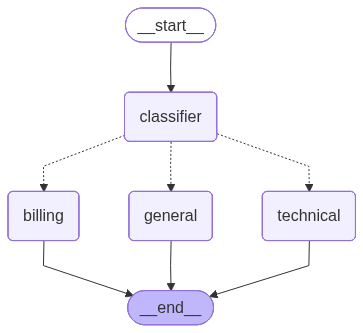

In [17]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7단계: 테스트 예제

다양한 문의 유형으로 챗봇을 테스트해봅니다.


### 테스트 케이스 1: 기술 지원 문의


In [18]:
question1 = "앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?"

# 초기 상태 생성
initial_state = {
    "question": question1
}

# 그래프 실행
result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: technical
[라우터] 'technical' 카테고리로 라우팅
[기술 지원 에이전트] 응답 생성 완료

질문: 앱이 자꾸 강제 종료됩니다. 어떻게 해야 하나요?
분류: technical

응답:
안녕하세요! 앱이 계속해서 강제 종료되는 문제로 불편을 겪고 계시다니 정말 안타깝습니다. 하지만 걱정 마세요. 제가 단계별로 해결 방법을 안내해 드리겠습니다. 문제 해결을 위해 몇 가지 단계를 밟아보겠습니다.

**1단계: 문제 재현 확인 및 정보 수집**

*   **정확한 상황 파악:** 앱을 사용할 때 어떤 상황에서 강제 종료가 발생하는지 자세히 기록해 주세요. 예를 들어, 특정 기능을 사용할 때, 앱을 처음 실행할 때, 특정 시간대에만 발생하는지 등을 알려주시면 문제 해결에 도움이 됩니다.
*   **오류 메시지 확인:** 강제 종료될 때 화면에 오류 메시지가 나타난다면, 정확한 메시지 내용을 기록해 주세요.
*   **앱 버전 확인:** 앱의 최신 버전인지 확인하고, 업데이트가 있다면 최신 버전으로 업데이트해 주세요.
*   **기기 모델 및 OS 버전 확인:** 사용 중인 기기 모델명과 운영체제 버전을 알려주시면, 해당 기기에서 발생하는 문제인지 확인하는 데 도움이 됩니다. (예: 삼성 갤럭시 S23, 안드로이드 13)

**2단계: 기본적인 해결 방법 시도**

*   **기기 재부팅:** 가장 간단하지만 효과적인 방법 중 하나입니다. 기기를 재부팅하면 일시적인 오류가 해결될 수 있습니다.
*   **앱 데이터 삭제:** 앱의 데이터 및 캐시를 삭제하면 앱이 정상적으로 작동하는 데 도움이 될 수 있습니다.
    *   **안드로이드:** 설정 > 앱 > 문제 해결 > 앱 데이터 삭제 (주의: 데이터 삭제 시 앱 설정 및 저장된 데이터가 삭제될 수 있습니다.)
    *   **iOS:** 설정 > 앱 > [앱 이름] > 저장공간 관리 > 모든 데이터 삭제 (주의: 데이터 삭제 시 앱 설정 및 저장된 데이터가 삭제될 수 

#### [Langsmith](https://smith.langchain.com/)

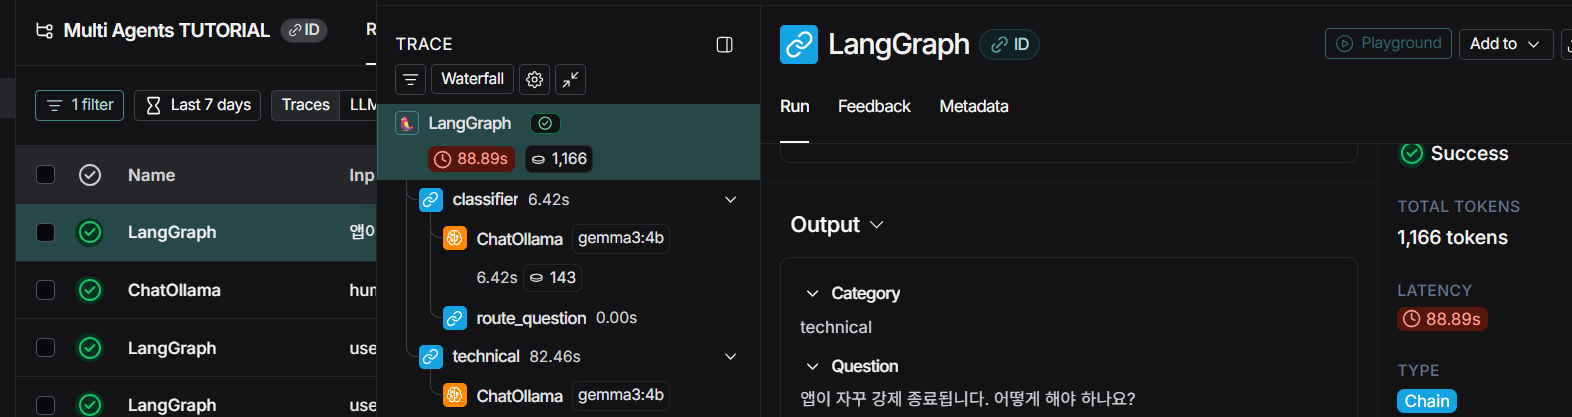

### 테스트 케이스 2: 결제 지원 문의


In [19]:
question2 = "구독을 취소하고 환불받고 싶습니다."

initial_state = {
    "question": question2
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: billing
[라우터] 'billing' 카테고리로 라우팅
[결제 지원 에이전트] 응답 생성 완료

질문: 구독을 취소하고 환불받고 싶습니다.
분류: billing

응답:
안녕하세요. 고객님, 구독 취소 및 환불 문의 주셔서 감사합니다. 불편을 드려 죄송합니다. 

고객님의 상황을 정확히 파악하고 도움을 드리기 위해 몇 가지 질문을 드려도 될까요?

1.  **어떤 서비스에 대한 구독을 취소하고 싶으신가요?** (예: 월간 멤버십, 연간 구독 등)
2.  **구독 계정 정보 (이메일 주소 또는 전화번호)를 알려주실 수 있나요?** 계정 정보를 통해 고객님의 구독 내역을 확인하고 정확한 환불 절차를 안내해 드릴 수 있습니다.
3.  **환불을 요청하시는 이유가 있으신가요?** (예: 서비스 이용 불량, 개인적인 사유 등)
4.  **원하시는 환불 금액은 얼마인가요?** (예: 잔여 기간에 대한 환불, 전체 환불 등)

**일반적인 구독 취소 및 환불 정책은 다음과 같습니다.**

*   **구독 취소:** 구독 취소는 계정 정보 확인 후 진행되며, 취소 시점부터 해당 서비스 이용은 중단됩니다.
*   **환불 정책:**
    *   **잔여 기간 환불:** 구독 기간이 남아있는 경우, 잔여 기간에 해당하는 요금의 50%를 환불해 드립니다. (단, 서비스 종류에 따라 환불 비율이 다를 수 있습니다.)
    *   **전체 환불:** 구독 기간이 지나고 취소하는 경우, 환불은 불가능합니다.
    *   **환불 요청 시 유의사항:** 환불 요청은 서비스 이용 후 진행되며, 환불 가능 여부는 서비스 종류 및 환불 정책에 따라 달라질 수 있습니다.

**환불 절차는 다음과 같습니다.**

1.  **계정 확인:** 고객님의 계정 정보를 확인하여 구독 내역을 확인합니다.
2.  **환불 가능 여부 확인:** 환불 가능 여부를 확인하고, 환불 금액을 산정합니다.
3.  **환불 승인:** 환불 승인을 한 후, 환불 진행 절차를 안내해

### 테스트 케이스 3: 일반 상담 문의


In [20]:
question3 = "프리미엄 플랜에는 어떤 기능들이 포함되나요?"

initial_state = {
    "question": question3
}

result = app.invoke(initial_state)

print(f"\n질문: {result['question']}")
print(f"분류: {result['category']}")
print(f"\n응답:\n{result['response']}")
print("=" * 60)


[분류 에이전트] 문의 유형: general
[라우터] 'general' 카테고리로 라우팅
[일반 상담 에이전트] 응답 생성 완료

질문: 프리미엄 플랜에는 어떤 기능들이 포함되나요?
분류: general

응답:
안녕하세요! 프리미엄 플랜에 대해 문의주셔서 감사합니다. 프리미엄 플랜은 저희 서비스를 최대한 활용하실 수 있도록 설계된 가장 강력한 플랜입니다. 주요 기능은 다음과 같습니다.

**1. 무제한 사용:**

*   저장 공간: 파일, 이미지, 비디오 등 모든 종류의 파일을 무제한으로 저장할 수 있습니다.
*   업로드/다운로드: 파일 크기나 용량 제한 없이 자유롭게 업로드 및 다운로드 할 수 있습니다.
*   API 호출: 개발자분들을 위한 API 호출 횟수 제한이 없습니다.

**2. 고급 기능:**

*   **자동 백업:** 중요한 데이터를 자동으로 백업하여 데이터 손실 위험을 최소화합니다. (매일, 매주, 매월 등 원하는 간격으로 설정 가능)
*   **우선 지원:** 일반 플랜 사용자보다 빠른 응답 속도로 고객 지원을 받으실 수 있습니다. (이메일, 채팅, 전화 등 다양한 채널 지원)
*   **팀 협업:** 최대 10명까지 팀원들과 함께 파일을 공유하고 협업할 수 있는 기능을 제공합니다. (파일 공유 권한 관리, 공동 편집 기능 등)
*   **보안 강화:** 데이터 암호화, 접근 제어 등 보안 기능을 강화하여 더욱 안전하게 데이터를 관리할 수 있습니다.
*   **맞춤형 보고서:** 데이터 분석 및 활용을 위한 맞춤형 보고서를 생성할 수 있습니다.

**3. 추가 혜택:**

*   **월별 컨설팅:** 서비스 활용에 대한 전문적인 컨설팅을 매월 1회 제공합니다.
*   **특별 이벤트 초대:** 신규 기능 출시, 이벤트 등 특별한 행사에 먼저 참여할 수 있는 기회를 제공합니다.

**프리미엄 플랜 가격:**

*   월간: 99,000원
*   연간: 999,000원 (월 할인 혜택 제공)

**자세한 정보:**

*   **가격 및 